# 06. 系列モデル — RNN・LSTM・GRU

## この章で分かること

- **再帰結合 (recurrence)** で可変長の系列を扱う仕組み
- 隠れ状態 $h_t$ が「過去の要約」であること
- 系列での **勾配消失** と、それを **ゲート** で克服する LSTM / GRU
- 正弦波・ノイズ付き正弦波・自己回帰過程の予測

CNN が空間方向の重み共有なら、RNN は **時間方向の重み共有** です。
同じセルを各時刻で使い回し、隠れ状態を引き継いでいきます。

```{admonition} 核心 — ひとことで
:class: tip
**RNN は「時間方向の重み共有」。隠れ状態 $h_t$ が過去の要約を運び、同じセルを各時刻で使い回す。**
素朴な RNN は BPTT で $W_{hh}$ の積が縮み、長期依存が学べない（時間方向の勾配消失）。
LSTM/GRU は**ゲート**でセル状態の素通し経路（忘却ゲート $f_t\approx1$）を作り記憶を保つ — 残差接続と同じ発想。
```

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from nn_textbook import datasets, plotting
from nn_textbook.training import get_device, set_seed, train_torch

set_seed(0)
# Committed outputs use the CPU; set NN_TEXTBOOK_GPU=1 to run on the GPU.
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
np.set_printoptions(precision=3, suppress=True)
print("device:", device)

device: cpu


## 1. Intuition — 隠れ状態は「ここまでの要約」

RNN は系列 $x_1, x_2, \dots, x_T$ を 1 ステップずつ読み、
隠れ状態 $h_t$ を更新していきます。

$$
h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h)
$$

- $h_t$: 時刻 $t$ までの情報の要約(固定長ベクトル)
- $W_{xh}, W_{hh}$: **全時刻で共有** される重み(これが「再帰」)
- 予測は $h_t$ から作る($\hat{y}_t = h_t W_{hy} + b_y$)

「過去を 1 個のベクトルに畳み込みながら前進する」のが核心です。
まず自作 RNN セルで隠れ状態がどう変化するか見ます。

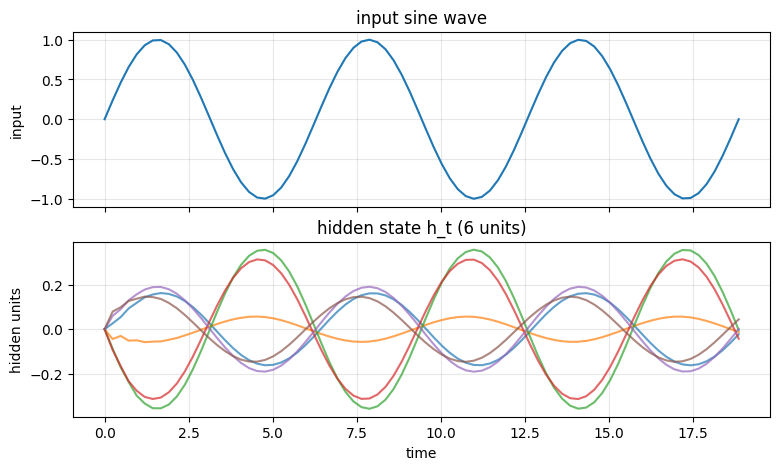

hidden state shape (T, hidden): (80, 6)


In [2]:
# A from-scratch RNN cell: watch the hidden state evolve along a sine wave.
from nn_textbook.models import NumpyRNNCell

t, wave = datasets.make_sine_wave_dataset(n_steps=80, periods=3.0)
cell = NumpyRNNCell(input_size=1, hidden_size=6, seed=0)
hidden_states = cell.run(wave[:, None])     # (T, hidden=6)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, wave); axes[0].set_ylabel("input"); axes[0].set_title("input sine wave"); axes[0].grid(alpha=0.3)
for j in range(hidden_states.shape[1]):
    axes[1].plot(t, hidden_states[:, j], alpha=0.7)
axes[1].set_ylabel("hidden units"); axes[1].set_xlabel("time"); axes[1].set_title("hidden state h_t (6 units)")
axes[1].grid(alpha=0.3)
plt.show()
print("hidden state shape (T, hidden):", hidden_states.shape)

各隠れユニットが、入力の位相に応じて滑らかに振動しています。
学習前(ランダム重み)でも、隠れ状態は入力の履歴を反映しています。

## 2. Definition — RNN を使った 1 ステップ予測

時系列予測のタスク: 過去 $w$ ステップ(ウィンドウ)から次の 1 ステップを当てる。

- 入力 $X$: shape $(N, w, 1)$ — $N$ サンプル、各 $w$ 時刻、特徴 1 次元
- 出力 $Y$: shape $(N, 1)$ — 次の値

`nn_textbook.models.make_rnn` は `nn.RNN/LSTM/GRU` + 線形ヘッドで、
最後の隠れ状態から次の値を予測します(`batch_first=True`)。

In [3]:
# Build supervised windows from a sine wave and set up loaders.
def make_loaders(series, window=20, batch=64, val_frac=0.3):
    X, Y = datasets.make_sequence_windows(series, window=window, horizon=1)
    n_val = int(len(X) * val_frac)
    Xtr, Ytr = X[:-n_val], Y[:-n_val]
    Xva, Yva = X[-n_val:], Y[-n_val:]
    tr = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(Ytr)), batch_size=batch, shuffle=True)
    va = DataLoader(TensorDataset(torch.tensor(Xva), torch.tensor(Yva)), batch_size=128)
    return tr, va, (Xtr, Ytr, Xva, Yva)


t, clean = datasets.make_sine_wave_dataset(n_steps=600, periods=8.0)
tr_loader, va_loader, arrs = make_loaders(clean, window=20)
print("input window shape (N, T, 1):", arrs[0].shape, " target shape:", arrs[1].shape)

input window shape (N, T, 1): (406, 20, 1)  target shape: (406, 1)


## 3. Computation — RNN / LSTM / GRU を比べる

3 種類を同じデータで学習し、予測精度を比べます。

In [4]:
# Train RNN, LSTM, GRU on the clean sine wave; compare validation MSE.
from nn_textbook.models import make_rnn

results = {}
for kind in ["rnn", "lstm", "gru"]:
    set_seed(0)
    model = make_rnn(kind=kind, input_size=1, hidden_size=32)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    h = train_torch(model, tr_loader, loss_fn=nn.MSELoss(), optimizer=opt,
                    epochs=40, device=device, val_loader=va_loader)
    results[kind] = (model, h)
    print(f"{kind.upper():>4}: final val MSE = {h['val_loss'][-1]:.5f}")

 RNN: final val MSE = 0.00001


LSTM: final val MSE = 0.00001


 GRU: final val MSE = 0.00000


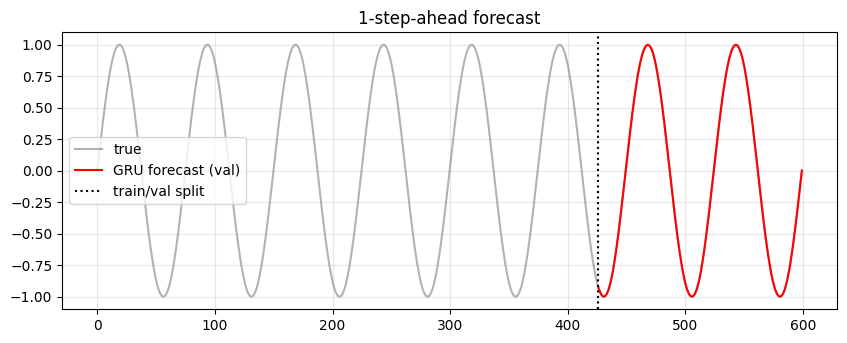

In [5]:
# Visualize the GRU's forecast over the validation region.
model = results["gru"][0]
Xtr, Ytr, Xva, Yva = arrs
model.eval()
with torch.no_grad():
    pred = model(torch.tensor(Xva).to(device)).cpu().numpy().ravel()

split = len(Ytr)
full_t = np.arange(len(clean))
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(full_t, clean, color="gray", alpha=0.6, label="true")
val_t = np.arange(split + 20, split + 20 + len(pred))
ax.plot(val_t, pred, "r", lw=1.5, label="GRU forecast (val)")
ax.axvline(split + 20, color="k", ls=":", label="train/val split")
ax.legend(); ax.grid(alpha=0.3); ax.set_title("1-step-ahead forecast")
plt.show()

## 4. 系列での勾配消失

RNN の隠れ状態は $h_t = \tanh(\dots h_{t-1}\dots)$ と再帰します。
逆伝播は時間方向に展開され(**BPTT: Backprop Through Time**)、
$h_T$ から $h_1$ への勾配は $W_{hh}$ の積を含みます。
この積が長い系列で指数的に縮む/発散する — **時間方向の勾配消失/爆発** です。

系列長を変えて、入力初期への勾配がどう減衰するか測ります。

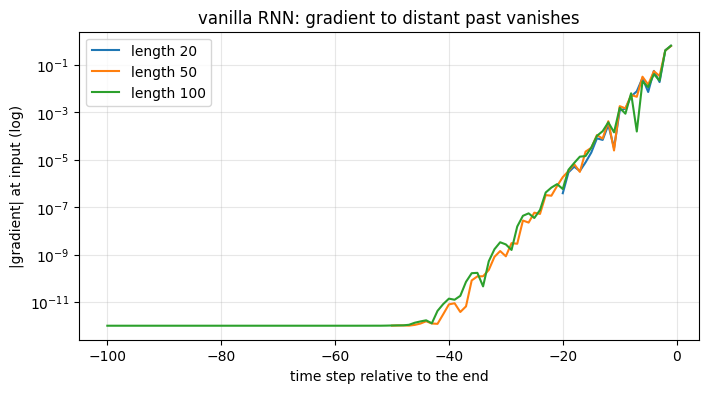

In [6]:
# Gradient from the last output back to early inputs decays with sequence length.
def gradient_decay(seq_len, hidden=16):
    set_seed(0)
    rnn = nn.RNN(input_size=1, hidden_size=hidden, batch_first=True)
    x = torch.randn(1, seq_len, 1, requires_grad=True)
    out, _ = rnn(x)
    out[:, -1, :].sum().backward()              # gradient of last step output
    # Norm of gradient at each input time step.
    return x.grad[0, :, 0].abs().numpy()


fig, ax = plt.subplots(figsize=(8, 4))
for L in [20, 50, 100]:
    g = gradient_decay(L)
    ax.semilogy(np.arange(L) - L, g + 1e-12, label=f"length {L}")
ax.set_xlabel("time step relative to the end"); ax.set_ylabel("|gradient| at input (log)")
ax.set_title("vanilla RNN: gradient to distant past vanishes")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()

遠い過去ほど勾配が小さく、長期依存が学べません。
これを解決するのが **ゲート機構** をもつ LSTM / GRU です。

## 5. Definition — LSTM のゲート

LSTM は隠れ状態に加えて **セル状態 $c_t$**(長期記憶)を持ち、
3 つのゲートで情報の流れを制御します。

- **忘却ゲート** $f_t$: 過去の記憶をどれだけ残すか
- **入力ゲート** $i_t$: 新しい情報をどれだけ書き込むか
- **出力ゲート** $o_t$: 記憶をどれだけ出力するか

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t, \qquad h_t = o_t \odot \tanh(c_t)
$$

ここで $\odot$ は要素ごとの積、各ゲートは $[0,1]$ の値(sigmoid)。
忘却ゲートが 1 に近ければ $c_t \approx c_{t-1}$ となり、記憶が **そのまま** 伝わる経路ができます
(04 章の残差接続と同じ発想)。これが長期依存を保つ鍵です。

GRU は LSTM を簡略化(ゲート 2 つ、セル状態なし)したもので、しばしば同等の性能です。

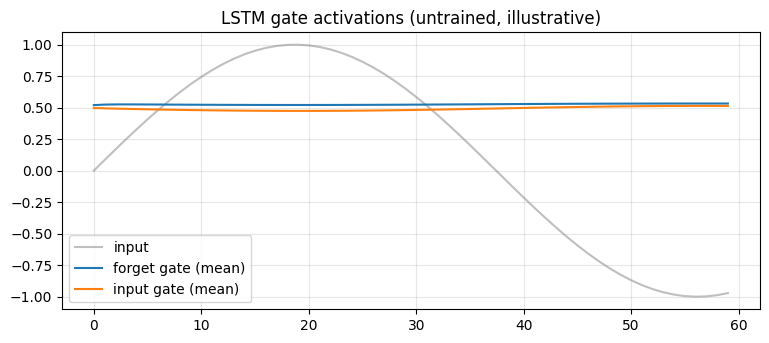

In [7]:
# Watch LSTM gate activations over a sine input: gates open and close in rhythm.
lstm = nn.LSTM(input_size=1, hidden_size=8, batch_first=True)
seq = torch.tensor(clean[:60], dtype=torch.float32).reshape(1, -1, 1)

# Manually unroll to read the gates (recompute the standard LSTM equations).
W_ii, W_if, W_ig, W_io = lstm.weight_ih_l0.chunk(4, 0)
W_hi, W_hf, W_hg, W_ho = lstm.weight_hh_l0.chunk(4, 0)
b_ii, b_if, b_ig, b_io = lstm.bias_ih_l0.chunk(4, 0)
b_hi, b_hf, b_hg, b_ho = lstm.bias_hh_l0.chunk(4, 0)

h = torch.zeros(8); c = torch.zeros(8)
forget_vals, input_vals = [], []
with torch.no_grad():
    for xt in seq[0]:
        f = torch.sigmoid(xt @ W_if.T + b_if + h @ W_hf.T + b_hf)
        i = torch.sigmoid(xt @ W_ii.T + b_ii + h @ W_hi.T + b_hi)
        g = torch.tanh(xt @ W_ig.T + b_ig + h @ W_hg.T + b_hg)
        o = torch.sigmoid(xt @ W_io.T + b_io + h @ W_ho.T + b_ho)
        c = f * c + i * g
        h = o * torch.tanh(c)
        forget_vals.append(f.mean().item()); input_vals.append(i.mean().item())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(clean[:60], color="gray", alpha=0.5, label="input")
ax.plot(forget_vals, label="forget gate (mean)")
ax.plot(input_vals, label="input gate (mean)")
ax.legend(); ax.grid(alpha=0.3); ax.set_title("LSTM gate activations (untrained, illustrative)")
plt.show()

### ▶ 触って確かめる — 記憶はどれだけ続くか（減衰スライダー）

忘却ゲートは「記憶をどれだけ残すか」を決めます。これを最も単純な形で見ると、状態が毎ステップ $a$ 倍に減衰する系の
**インパルス応答** $a^t$ です。スライダーで減衰率 $a$ を上げると記憶が長く尾を引きます（$a\to1$ で残差接続のように素通し）—
長期依存を保つゲートの本質が見えます。

In [8]:
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
fig = plotting.plotly_ssm_impulse(title="記憶の減衰：忘却ゲート a の効果（a→1 で長期記憶）")
fig.show()

## 6. ノイズ付き系列と自己回帰過程

実データはノイズを含みます。ノイズ付き正弦波と AR 過程で、
LSTM がトレンドを捉えつつノイズを平滑化できるか見ます。

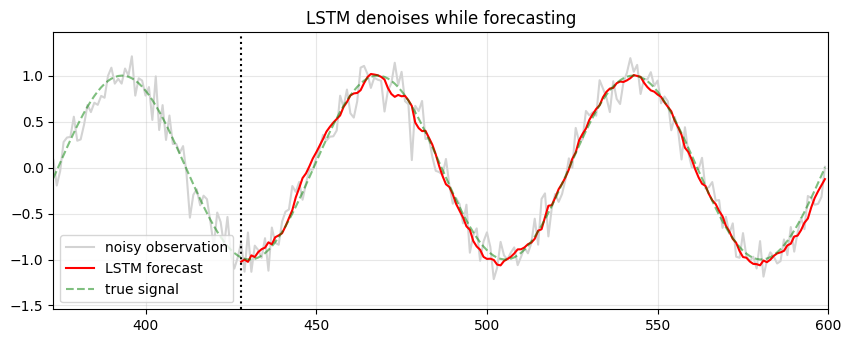

In [9]:
# LSTM on a noisy sine wave: it tracks the signal through the noise.
t_n, noisy = datasets.make_noisy_sine_wave_dataset(n_steps=600, periods=8.0, noise=0.15, seed=0)
tr_loader, va_loader, arrs = make_loaders(noisy, window=25)

set_seed(0)
model = make_rnn(kind="lstm", hidden_size=32)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
train_torch(model, tr_loader, loss_fn=nn.MSELoss(), optimizer=opt, epochs=40, device=device, val_loader=va_loader)

Xtr, Ytr, Xva, Yva = arrs
model.eval()
with torch.no_grad():
    pred = model(torch.tensor(Xva).to(device)).cpu().numpy().ravel()
split = len(Ytr)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(noisy, color="lightgray", label="noisy observation")
val_t = np.arange(split + 25, split + 25 + len(pred))
ax.plot(val_t, pred, "r", lw=1.5, label="LSTM forecast")
ax.plot(np.sin(t_n), "g--", alpha=0.5, label="true signal")
ax.axvline(split + 25, color="k", ls=":")
ax.set_xlim(split - 30, len(noisy)); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("LSTM denoises while forecasting")
plt.show()

AR process: final val MSE = 0.0444  (process noise variance ~ 0.040)


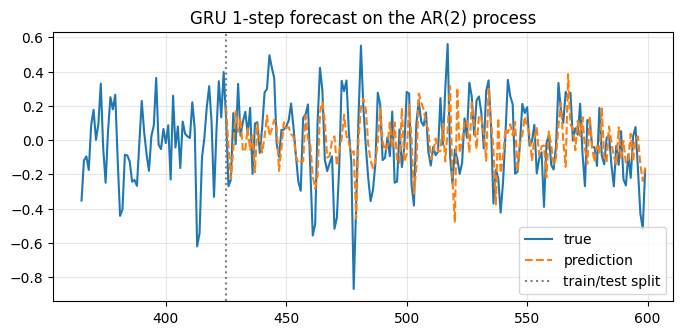

In [10]:
# Autoregressive process: a tougher target with its own dynamics.
ar = datasets.make_ar_process_dataset(n_steps=600, coeffs=(0.6, -0.3), noise=0.2, seed=0)
tr_loader, va_loader, arrs = make_loaders(ar, window=15)

set_seed(0)
model = make_rnn(kind="gru", hidden_size=32)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
h = train_torch(model, tr_loader, loss_fn=nn.MSELoss(), optimizer=opt, epochs=50, device=device, val_loader=va_loader)
print(f"AR process: final val MSE = {h['val_loss'][-1]:.4f}  (process noise variance ~ {0.2**2:.3f})")

# Forecast plot over the validation tail, with the train/val split marked.
Xtr, Ytr, Xva, Yva = arrs
model.eval()
with torch.no_grad():
    pred_ar = model(torch.tensor(Xva).to(device)).cpu().numpy().ravel()
t_idx = np.arange(len(ar))
split = len(Ytr) + 15          # first index the validation forecasts refer to
window_start = split - 60      # show 60 steps of context before the split
plotting.plot_sequence_prediction(
    t_idx[window_start:], ar[window_start:],
    pred=pred_ar, split_idx=60,
    title="GRU 1-step forecast on the AR(2) process",
)
plt.show()

## 7. Failure Mode — RNN の限界

- **長期依存**: ゲート付きでも数百ステップを超える依存は苦手。
- **逐次計算**: 時刻を 1 つずつ処理するため並列化しにくく、長系列で遅い。
- **勾配爆発**: 対策は勾配クリッピング(`clip_grad_norm_`、04 章 / `train_torch` の `grad_clip`)。

これらの限界、特に「逐次性」と「長期依存」を一気に解決したのが
**注意機構 (attention)** と **Transformer** で、次章の主役です。

## 8. Application — 系列モデルの応用

- 時系列予測(需要・気象・センサ)、異常検知
- 音声認識・音声合成(かつての主力)
- 自然言語処理(機械翻訳・言語モデル) — Transformer 登場前の標準

今日では多くが Transformer に置き換わりましたが、
RNN は軽量・低遅延・ストリーミング処理に向き、組み込みやリアルタイム用途で現役です。

```{admonition} 実社会では
:class: important
系列モデルは「順番が意味を持つデータ」のための道具です。

- 時系列予測（需要・気象・センサ）・異常検知、音声認識／合成。
- 多くは Transformer に置き換わったが、RNN は軽量・低遅延・ストリーミングで現役（組み込み・リアルタイム）。
- 「逐次計算で並列化しにくい」という限界が、次章の注意機構（Transformer）を生んだ。
```

## 9. まとめ

- RNN は **時間方向の重み共有**。隠れ状態 $h_t$ が「ここまでの要約」を運ぶ。
- BPTT では $W_{hh}$ の積が繰り返され、長い系列で勾配が **消える / 爆発する**。
- **LSTM / GRU** はゲートでセル状態の「素通し経路」を作り、長期依存を保つ(残差接続と同じ発想)。
- ウィンドウ化(`make_sequence_windows`)で系列予測は教師あり学習に落ちる。shape は (N, T, 1)。
- 逐次計算ゆえ並列化が苦手 — この限界を注意機構が破る(07 章)。

## 10. Exercises

1. ウィンドウ幅 $w$ を 5 / 20 / 50 と変え、正弦波予測の精度がどう変わるか調べよ。
2. `gradient_decay` の隠れ次元や活性化を変え、減衰の速さがどう変わるか観察せよ。
3. LSTM と GRU を AR 過程で比較し、パラメータ数と精度のトレードオフを述べよ。
4. ノイズ付き正弦波の `noise` を 0.3 に上げ、予測がどこまで平滑化できるか見よ。
5. 学習に勾配クリッピング(`train_torch(..., grad_clip=1.0)`)を入れ、効果を確認せよ。
6. (発展)複数ステップ先(horizon>1)予測に拡張し、予測が遠い未来で崩れる様子を観察せよ。

## 11. Advanced Notes

**BPTT と truncation。** 長系列の BPTT はメモリ・計算が系列長に比例します。
実務では一定長で打ち切る **truncated BPTT** を使い、勾配を一定窓だけ遡らせます。

**LSTM がなぜ勾配消失に強いか。** セル状態の更新 $c_t = f_t \odot c_{t-1} + \dots$ は、
忘却ゲート $f_t \approx 1$ のとき $\partial c_t/\partial c_{t-1} \approx 1$ となり、
勾配が減衰せず流れます(「constant error carousel」)。tanh の積で潰れる vanilla RNN との差です。

**双方向・多層 RNN。** 過去だけでなく未来も使う双方向 RNN(系列全体が手元にある場合)、
隠れ状態を積み重ねる多層 RNN で表現力を上げられます。`nn.LSTM(..., bidirectional=True, num_layers=k)`。

**RNN から Transformer へ。** RNN の逐次性は学習の並列化を妨げます。
Transformer は再帰を捨て、系列の全ペア間の関係を **注意** で一度に計算することで、
並列学習と長期依存の両方を獲得しました(07 章)。